<a href="https://colab.research.google.com/github/anafer25/High-Accuracy-Forward-Difference-Derivative-Using-Taylor-Series/blob/main/High_Accuracy_Forward_Difference_Derivative_Using_Taylor_Series.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In this project, I derive a forward finite difference approximation for the derivative operator using a Taylor series expansion, designed to achieve fourth-order accuracy while using only function values at current and forward points. The analytic derivation eliminates the leading error term by appropriately combining approximations with different step sizes. I then verify this result computationally by modifying the derivative calculator class and plotting the absolute error of the derivative of the function f(x) = x^6
against the square of the step size. This allows me to observe the convergence of the approximation as the step size decreases.

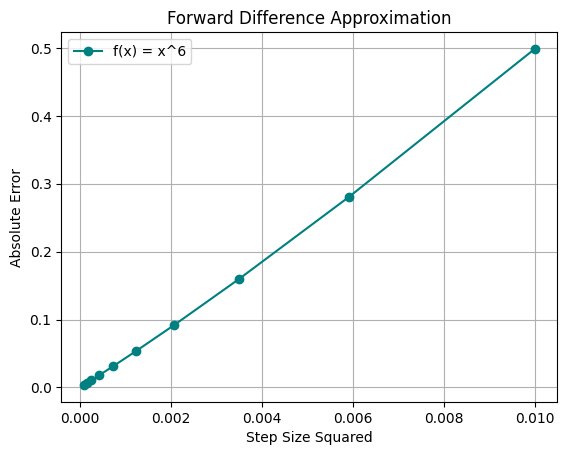

In [2]:
import numpy as np
import matplotlib.pyplot as plt

# define a sample function: f(x) = x^6
def power_six(x):
    return x**6

class ForwardDerivative:
  '''class to compute the forward finite difference derivative
  '''
  def __init__(self, func, step):
        self.func = func       # function whose derivative we want
        self.__step = step     # step size for finite difference

  def get_step(self):
    '''Getter for step size
    '''
    return self.__step

  def set_step(self, step):
    '''Setter to update step size
    '''
    self.__step = step

  def derivative(self, x):
    '''Compute the derivative using a 4th-order forward difference
    '''
    h = self.get_step()
    return (-self.func(x + 2*h) + 4*self.func(x + h) - 3*self.func(x)) / (2*h)

# initialize variables
initial_step = 0.1
x_vals = np.zeros(10)
errors = np.zeros(10)

# create derivative calculator
deriv_calc = ForwardDerivative(power_six, initial_step)

# loop to compute error for decreasing step sizes
for i in range(10):
    exact_derivative = 6  # f'(1) for x^6 is 6
    errors[i] = np.abs(deriv_calc.derivative(1.0) - exact_derivative)
    x_vals[i] = deriv_calc.get_step()**2
    # reduce step size for next iteration
    deriv_calc.set_step(deriv_calc.get_step() / 1.3)

# plot the error vs step size squared
plt.plot(x_vals, errors, marker='o', color='teal', label='f(x) = x^6')
plt.xlabel('Step Size Squared')
plt.ylabel('Absolute Error')
plt.title('Forward Difference Approximation')
plt.grid(True)
plt.legend()
plt.show()

